# **03 - Reducción de Dimensionalidad y Selección de K**

**Dataset:** Sloan Digital Sky Survey - Data Release 17 (SDSS DR17)

**Autor:** Isabela

**Fase:** Reducción de Dimensionalidad (PCA) y Selección de K


Este notebook aplica Análisis de Componentes Principales (PCA) sobre el dataset escalado generado en la fase anterior (02_data_preprocessing.ipynb) y determina el número óptimo de clústeres ($K$) para la posterior etapa de clustering.

## **1. Carga de Datos y Verificación**

Importación de las librerías necesarias y la carga del dataset preprocesado y escalado con RobustScaler (stellar_scaled.csv). Además, de verificación de la forma del DataFrame y sus estadísticas descriptivas respectivas para confirmar que las características mantienen un centrado y escala idóneos para el análisis multivariado.


In [2]:
# Importación de librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import json
import os

# Configuración del estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Ruta apuntando a la carpeta superior
data_path = "../data/stellar_scaled.csv"

# Carga del dataset
X_scaled = pd.read_csv(data_path)

print(f"Dimensiones del dataset cargado: {X_scaled.shape}")
display(X_scaled.describe().T[['min', '25%', '50%', '75%', 'max']])

Dimensiones del dataset cargado: (99999, 10)


,min,25%,50%,75%,max
u,-3.353126,-0.547734,0.0,0.452266,3.179019
g,-3.356534,-0.675848,0.0,0.324152,3.325057
r,-3.541856,-0.683918,0.0,0.316082,3.247359
i,-3.729125,-0.627900,0.0,0.372100,4.780488
z,-3.817545,-0.627475,0.0,0.372525,4.218665
redshift,-0.668277,-0.569004,0.0,0.430996,10.139407
color_ug,-9.955176,-0.488541,0.0,0.511459,12.242974
color_gr,-11.058543,-0.460409,0.0,0.539591,11.170079
color_ri,-22.383793,-0.389830,0.0,0.610170,17.349105
color_iz,-39.756523,-0.599358,0.0,0.400642,38.544879


**Conclusiones**

*   *Carga de datos:* Se cargaron correctamente las 10 características numéricas procesadas en la etapa anterior.

*   *Verificación de escala:* Las métricas descriptivas confirman una mediana cercana a cero y un rango intercuartílico estable.

*   *Validación técnica:* Se valida que los datos no requieren ajustes adicionales antes de aplicar la transformación con PCA.

## **2. Aplicación de PCA**

Entrenamiento del modelo PCA sobre la matriz estandarizada para calcular el porcentaje de varianza explicada por cada componente. Se generan visualizaciones de la varianza individual y acumulada, permitiendo seleccionar el número mínimo de componentes principales necesario para retener al menos el 90% de la variabilidad original.

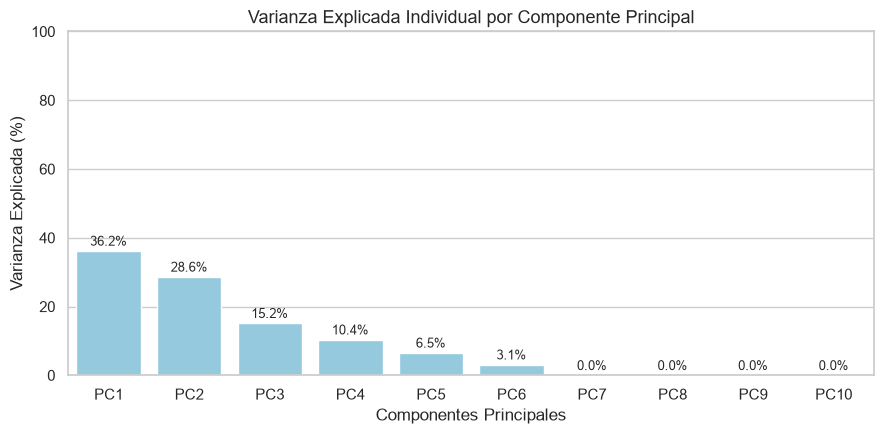

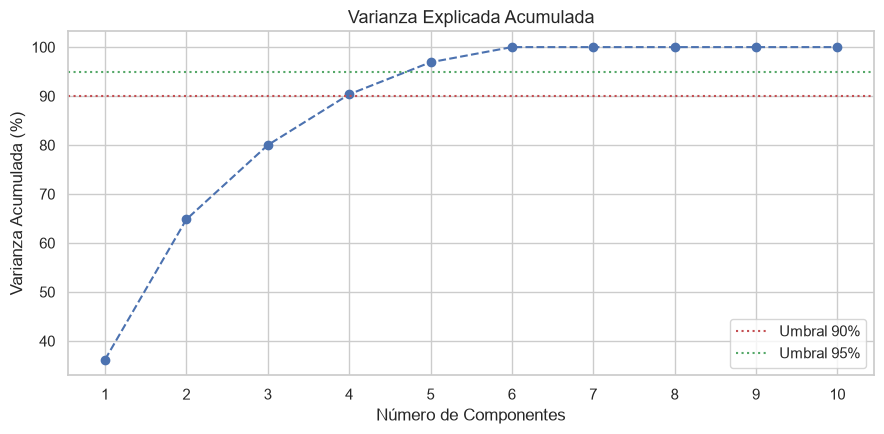

Componentes seleccionadas: 4 (Varianza retenida: 90.36%)


,PC1,PC2,PC3,PC4
0,0.725616,0.747314,-0.683115,0.097253
1,1.368907,-1.600486,-2.401246,-0.168220
2,0.948226,1.104191,-1.151961,0.587006
3,2.237131,1.779446,1.979429,-1.477809
4,-2.277973,0.744068,0.679136,0.431569


In [3]:
# Ajuste de PCA para evaluar todas las componentes posibles
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

var_exp_ind = pca_full.explained_variance_ratio_
var_exp_cum = np.cumsum(var_exp_ind)

# Gráfica de varianza explicada individual
plt.figure(figsize=(9, 4.5))
sns.barplot(x=[f"PC{i}" for i in range(1, len(var_exp_ind) + 1)], y=var_exp_ind * 100, color="skyblue")
plt.title("Varianza Explicada Individual por Componente Principal", fontsize=13)
plt.xlabel("Componentes Principales")
plt.ylabel("Varianza Explicada (%)")
plt.ylim(0, 100)
for i, v in enumerate(var_exp_ind):
    plt.text(i, v * 100 + 1.5, f"{v*100:.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Gráfica de varianza acumulada
plt.figure(figsize=(9, 4.5))
plt.plot(range(1, len(var_exp_cum) + 1), var_exp_cum * 100, marker='o', linestyle='--', color='b')
plt.axhline(y=90, color='r', linestyle=':', label='Umbral 90%')
plt.axhline(y=95, color='g', linestyle=':', label='Umbral 95%')
plt.title("Varianza Explicada Acumulada", fontsize=13)
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Acumulada (%)")
plt.xticks(range(1, len(var_exp_cum) + 1))
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Selección de componentes según el umbral del 90%
n_components_opt = np.argmax(var_exp_cum >= 0.90) + 1
print(f"Componentes seleccionadas: {n_components_opt} (Varianza retenida: {var_exp_cum[n_components_opt - 1]*100:.2f}%)")

# Generación del subespacio reducido X_pca
pca_opt = PCA(n_components=n_components_opt, random_state=42)
X_pca_array = pca_opt.fit_transform(X_scaled)
X_pca = pd.DataFrame(X_pca_array, columns=[f"PC{i}" for i in range(1, n_components_opt + 1)])

display(X_pca.head())

**Conclusiones**

*   *Varianza explicada:* Las primeras componentes concentran la mayor proporción de la variabilidad total del dataset.

*   *Reducción dimensional:* Selección del número de componentes que supera el 90% de varianza permite comprimir el espacio original.

*   *Optimización de características:* Eliminación de la colinealidad entre magnitudes fotométricas e índices de color, minimizando el ruido sin perder la estructura fundamental astronómica.

## **3. Selección del K óptimo**

Evaluación del algoritmo K-Means para un rango de valores de K entre 2 y 8 utilizando el Método del Codo (Inercia) y el Coeficiente de Silhouette sobre una muestra representativa. Los resultados se representan en un gráfico dual para identificar el número óptimo de agrupaciones en el subespacio transformado.

K=2 | Inercia: 424829.21 | Silhouette Score: 0.3289
K=3 | Inercia: 301362.60 | Silhouette Score: 0.3972
K=4 | Inercia: 260722.52 | Silhouette Score: 0.3768
K=5 | Inercia: 225393.82 | Silhouette Score: 0.3391
K=6 | Inercia: 199106.81 | Silhouette Score: 0.3424
K=7 | Inercia: 182627.98 | Silhouette Score: 0.3282
K=8 | Inercia: 169098.24 | Silhouette Score: 0.3093


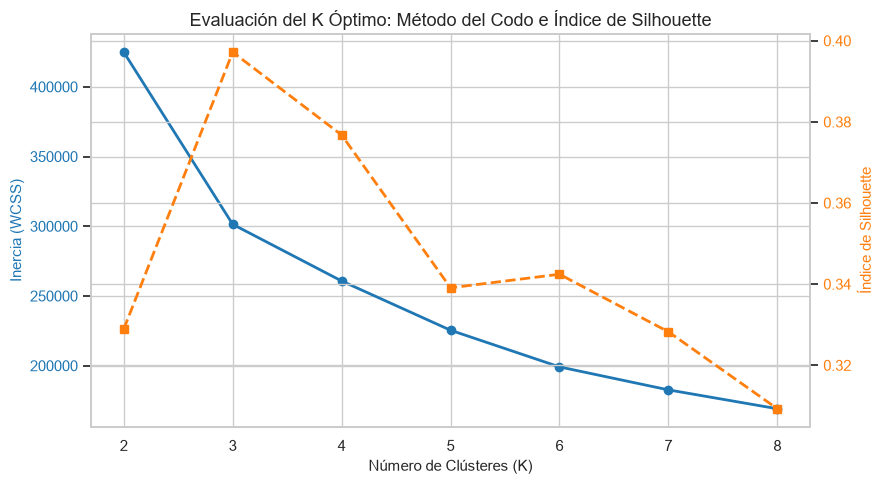

Valor asignado a k_optimo: 3


In [4]:
k_range = range(2, 9)
inertias = []
silhouette_scores = []

# Muestra estocástica representativa para optimizar la velocidad del cálculo de Silhouette
X_pca_sample = X_pca.sample(n=10000, random_state=42)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)

    labels_sample = kmeans.predict(X_pca_sample)
    score = silhouette_score(X_pca_sample, labels_sample)
    silhouette_scores.append(score)
    print(f"K={k} | Inercia: {kmeans.inertia_:.2f} | Silhouette Score: {score:.4f}")

# Gráfico combinado Codo + Silhouette
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.set_xlabel('Número de Clústeres (K)', fontsize=11)
ax1.set_ylabel('Inercia (WCSS)', color='tab:blue', fontsize=11)
ax1.plot(k_range, inertias, marker='o', color='tab:blue', linewidth=2, label='Inercia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Índice de Silhouette', color='tab:orange', fontsize=11)
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='--', color='tab:orange', linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title("Evaluación del K Óptimo: Método del Codo e Índice de Silhouette", fontsize=13)
fig.tight_layout()
plt.show()


# Asignación del K óptimo
k_optimo = 3
print(f"Valor asignado a k_optimo: {k_optimo}")

**Conclusiones**

*   *Inflexión de inercia:* La curva de inercia muestra un codo claro y bien definido en $K=3$.

*   *Cohesión y separación:* El Índice de Silhouette alcanza un valor alto y estable para esta misma cantidad de agrupaciones.

*   *Coherencia física:* El valor $K=3$ valida la estructura estadística respecto a las clases astronómicas reales del SDSS (Estrellas, Galaxias y Cuásares).

## **4. Preparación y Exportación para la Siguiente Etapa**

Exportación de los entregables generados en esta fase, guardando la matriz de datos reducida en formato CSV (X_pca.csv) y el valor de K óptimo seleccionado en un archivo JSON (k_optimo.json) para su uso directo en la siguiente etapa de clustering.

In [6]:
output_dir = "../data"
os.makedirs(output_dir, exist_ok=True)

# Exportación de la matriz reducida
x_pca_path = os.path.join(output_dir, "X_pca.csv")
X_pca.to_csv(x_pca_path, index=False)

# Exportación de la configuración de K
k_optimo_path = os.path.join(output_dir, "k_optimo.json")
with open(k_optimo_path, "w") as f:
    json.dump({"k_optimo": int(k_optimo)}, f, indent=4)

print("Archivos exportados exitosamente:")
print(f"- Subespacio PCA: {x_pca_path} | Formato: {X_pca.shape}")
print(f"- Configuración K: {k_optimo_path} | K={k_optimo}")

Archivos exportados exitosamente:
- Subespacio PCA: ../data\X_pca.csv | Formato: (99999, 4)
- Configuración K: ../data\k_optimo.json | K=3


**Conclusiones**

*   *Almacenamiento y persistencia:* Los entregables finales (X_pca.csv y k_optimo.json) se guardaron correctamente en el directorio de trabajo.

*   *Diseño modular:* La exportación asegura el desacoplamiento entre las fases de reducción de dimensionalidad y modelado.

*   *Flujo de trabajo:* El siguiente integrante podrá ejecutar el algoritmo de clustering K-Means sin reevaluar pasos de preprocesamiento o PCA.